In [320]:
import pandas as pd
import kagglehub

print("Pandas:", pd.__version__)
print("KaggleHub:", kagglehub.__version__)

Pandas: 3.0.5
KaggleHub: 1.0.2


In [321]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\amand\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [322]:
import os

print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [323]:
import pandas as pd

arquivo = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(arquivo)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [324]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 7043
Colunas: 21


In [325]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [326]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [327]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [328]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [329]:
df["TotalCharges"].unique()[:20]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [330]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [331]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [332]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [333]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [334]:
df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [335]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [336]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [337]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [338]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [339]:
df["customerID"].nunique()

7043

In [340]:
df["Churn"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [341]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [342]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [343]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [344]:
X = df.drop(columns=["Churn"])

In [345]:
y = df["Churn"]

In [346]:
X = df.drop(columns=["Churn"])

y = df["Churn"]

In [347]:
X.shape

(7043, 20)

In [348]:
from sklearn.model_selection import train_test_split

In [349]:
import pandas as pd

In [350]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print(path)

C:\Users\amand\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [351]:
import os

arquivo = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(arquivo)

In [352]:
df.shape

(7043, 21)

In [353]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [354]:
X = df.drop("Churn", axis=1)

In [355]:
y = df["Churn"]

In [356]:
X.shape

(7043, 20)

In [357]:
y.shape

(7043,)

In [358]:
from sklearn.model_selection import train_test_split

In [359]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [360]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 20)
(1409, 20)
(5634,)
(1409,)


In [361]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [362]:
df["TotalCharges"].dtype

dtype('float64')

In [363]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [364]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [365]:
print(X_train.shape)
print(X_test.shape)

(5634, 20)
(1409, 20)


In [366]:
X.select_dtypes(include="object").columns

C:\Users\amand\AppData\Local\Temp\ipykernel_21116\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [367]:
X = pd.get_dummies(X, drop_first=True)

X.shape

(7043, 7072)

In [368]:
X.dtypes.value_counts()

bool       7068
int64         2
float64       2
Name: count, dtype: int64

In [369]:
from sklearn.linear_model import LogisticRegression

In [370]:
model = LogisticRegression(max_iter=1000)

In [371]:
X.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'customerID_0003-MKNFE', 'customerID_0004-TLHLJ',
       'customerID_0011-IGKFF', 'customerID_0013-EXCHZ',
       'customerID_0013-MHZWF', 'customerID_0013-SMEOE',
       ...
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str', length=7072)

In [372]:
X = df.drop(columns=["Churn", "customerID"])

In [373]:
X = pd.get_dummies(X, drop_first=True)

In [374]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [375]:
X_train.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

In [376]:
X_train.isna().sum().sort_values(ascending=False)

TotalCharges                             8
SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMovies_No internet service      0
StreamingMo

In [377]:
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

In [378]:
X["TotalCharges"] = X["TotalCharges"].fillna(0)

In [379]:
X.isna().sum().sum()

np.int64(0)

In [380]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [381]:
X_train.isna().sum().sum()

np.int64(0)

In [382]:
X_train.isna().sum().sum()

np.int64(0)

In [383]:
X_test.isna().sum().sum()

np.int64(0)

In [384]:
model.fit(X_train, y_train)

c:\Users\amand\OneDrive\Documentos\AI-Data-Analyst\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [385]:
X_test

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,False,True,False,True,False,True,True,True,False,False
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,False,True,False,True,False,False,True,True,False,False
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,False,True,False,False,True,False,True,True,False,False
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,False,True,False,True,False,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0,49,87.20,4345.00,False,True,True,True,False,False,...,False,True,False,True,True,False,True,False,False,True
4439,0,28,20.30,487.95,True,True,True,True,False,False,...,True,False,True,False,False,True,True,True,False,False
3857,0,5,20.65,93.55,True,False,False,True,False,False,...,True,False,True,False,False,False,False,False,False,False
4758,0,56,19.70,1051.90,False,False,False,True,False,False,...,True,False,True,False,False,True,False,False,False,False


In [386]:
y_pred = model.predict(X_test)

In [387]:
y_pred

array(['No', 'Yes', 'No', ..., 'No', 'No', 'No'],
      shape=(1409,), dtype=object)

In [388]:
from sklearn.metrics import accuracy_score

In [389]:
accuracy_score

<function sklearn.metrics._classification.accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)>

In [390]:
accuracy = accuracy_score(y_test, y_pred)

In [391]:
accuracy

0.8041163946061036

In [392]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 110]
 [166 208]]


In [393]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [394]:
from sklearn.ensemble import RandomForestClassifier

In [395]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [396]:
model_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [397]:
y_pred_rf = model_rf.predict(X_test)

In [398]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [399]:
y_prob = model.predict_proba(X_test)[:, 1]

In [400]:
threshold = 0.40

y_pred_threshold = (y_prob >= threshold).astype(int)

In [401]:
import numpy as np

In [402]:
y_pred_threshold = np.where(y_prob >= threshold, "Yes", "No")

In [403]:
print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

          No       0.87      0.82      0.84      1035
         Yes       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [404]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_pred_threshold = np.where(y_prob >= threshold, "Yes", "No")
    
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred_threshold, digits=2))


Threshold: 0.3
              precision    recall  f1-score   support

          No       0.90      0.75      0.82      1035
         Yes       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409


Threshold: 0.35
              precision    recall  f1-score   support

          No       0.88      0.79      0.83      1035
         Yes       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409


Threshold: 0.4
              precision    recall  f1-score   support

          No       0.87      0.82      0.84      1035
         Yes       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79  

In [405]:
for threshold in thresholds:
    y_pred_threshold = np.where(y_prob >= threshold, "Yes", "No")
    
    report = classification_report(
        y_test,
        y_pred_threshold,
        output_dict=True
    )
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Recall Yes: {report['Yes']['recall']:.2f} | "
        f"Precision Yes: {report['Yes']['precision']:.2f} | "
        f"F1 Yes: {report['Yes']['f1-score']:.2f} | "
        f"Accuracy: {report['accuracy']:.2f}"
    )

Threshold: 0.30 | Recall Yes: 0.76 | Precision Yes: 0.52 | F1 Yes: 0.62 | Accuracy: 0.75
Threshold: 0.35 | Recall Yes: 0.70 | Precision Yes: 0.54 | F1 Yes: 0.61 | Accuracy: 0.76
Threshold: 0.40 | Recall Yes: 0.67 | Precision Yes: 0.57 | F1 Yes: 0.62 | Accuracy: 0.78
Threshold: 0.45 | Recall Yes: 0.62 | Precision Yes: 0.60 | F1 Yes: 0.61 | Accuracy: 0.79
Threshold: 0.50 | Recall Yes: 0.56 | Precision Yes: 0.65 | F1 Yes: 0.60 | Accuracy: 0.80
Threshold: 0.55 | Recall Yes: 0.47 | Precision Yes: 0.69 | F1 Yes: 0.55 | Accuracy: 0.80
Threshold: 0.60 | Recall Yes: 0.40 | Precision Yes: 0.72 | F1 Yes: 0.51 | Accuracy: 0.80


In [406]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variavel": X_train.columns,
    "Coeficiente": model.coef_[0]
})

coeficientes["Impacto_Absoluto"] = coeficientes["Coeficiente"].abs()

coeficientes = coeficientes.sort_values(
    "Impacto_Absoluto",
    ascending=False
)

coeficientes.head(15)

,Variavel,Coeficiente,Impacto_Absoluto
25,Contract_Two year,-1.328605,1.328605
10,InternetService_Fiber optic,0.744096,0.744096
24,Contract_One year,-0.685712,0.685712
7,PhoneService_Yes,-0.440448,0.440448
13,OnlineSecurity_Yes,-0.431675,0.431675
28,PaymentMethod_Electronic check,0.390784,0.390784
19,TechSupport_Yes,-0.384448,0.384448
26,PaperlessBilling_Yes,0.373610,0.373610
9,MultipleLines_Yes,0.274699,0.274699
6,Dependents_Yes,-0.221900,0.221900


In [407]:
coeficientes = pd.DataFrame({
    "Variavel": X_train.columns,
    "Coeficiente": model.coef_[0]
})

coeficientes = coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

coeficientes

,Variavel,Coeficiente
10,InternetService_Fiber optic,0.744096
28,PaymentMethod_Electronic check,0.390784
26,PaperlessBilling_Yes,0.373610
9,MultipleLines_Yes,0.274699
21,StreamingTV_Yes,0.198898
23,StreamingMovies_Yes,0.198237
8,MultipleLines_No phone service,0.166147
0,SeniorCitizen,0.145367
29,PaymentMethod_Mailed check,0.075469
5,Partner_Yes,0.023329


In [408]:
coeficientes.head(10)

,Variavel,Coeficiente
10,InternetService_Fiber optic,0.744096
28,PaymentMethod_Electronic check,0.390784
26,PaperlessBilling_Yes,0.373610
9,MultipleLines_Yes,0.274699
21,StreamingTV_Yes,0.198898
23,StreamingMovies_Yes,0.198237
8,MultipleLines_No phone service,0.166147
0,SeniorCitizen,0.145367
29,PaymentMethod_Mailed check,0.075469
5,Partner_Yes,0.023329


In [409]:
coeficientes.tail(10)

,Variavel,Coeficiente
18,TechSupport_No internet service,-0.109966
16,DeviceProtection_No internet service,-0.109966
20,StreamingTV_No internet service,-0.109966
15,OnlineBackup_Yes,-0.182348
6,Dependents_Yes,-0.221900
19,TechSupport_Yes,-0.384448
13,OnlineSecurity_Yes,-0.431675
7,PhoneService_Yes,-0.440448
24,Contract_One year,-0.685712
25,Contract_Two year,-1.328605


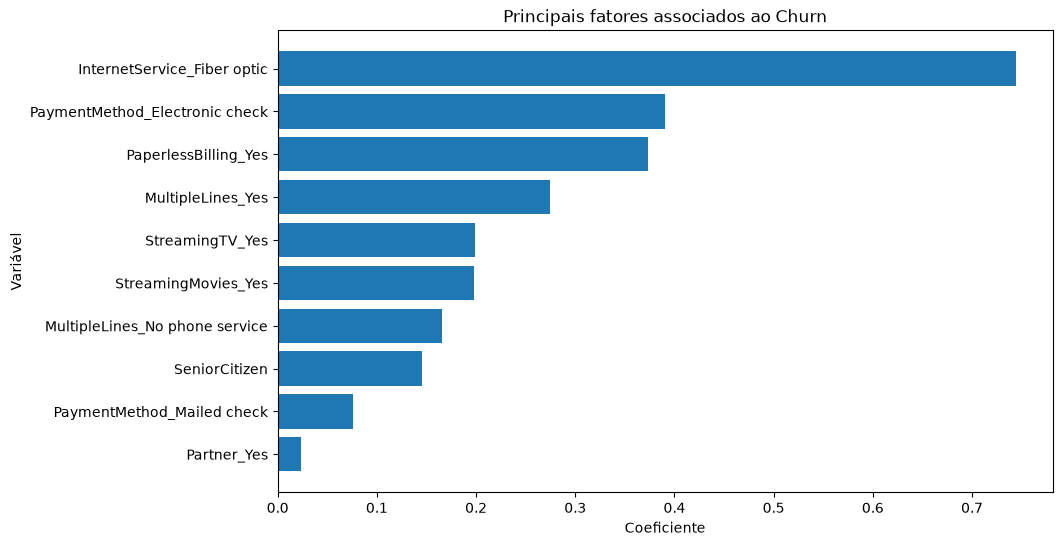

In [410]:
import matplotlib.pyplot as plt

top_10 = coeficientes.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Variavel"],
    top_10["Coeficiente"]
)

plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.title("Principais fatores associados ao Churn")

plt.gca().invert_yaxis()

plt.show()

In [411]:
probabilidades = model.predict_proba(X_test)[:, 1]

probabilidades[:10]

array([0.0466683 , 0.6818411 , 0.0632964 , 0.39189125, 0.02047635,
       0.59961026, 0.44163598, 0.12588432, 0.00268424, 0.39428747])

In [412]:
resultado = X_test.copy()

resultado["Probabilidade_Churn"] = probabilidades

resultado["Churn_Previsto"] = np.where(
    probabilidades >= 0.5,
    "Yes",
    "No"
)

resultado[["Probabilidade_Churn", "Churn_Previsto"]].head(10)

,Probabilidade_Churn,Churn_Previsto
437,0.046668,No
2280,0.681841,Yes
2235,0.063296,No
4460,0.391891,No
3761,0.020476,No
5748,0.599610,Yes
3568,0.441636,No
2976,0.125884,No
5928,0.002684,No
1639,0.394287,No


In [413]:
resultado["Churn_Previsto"] = np.where(
    resultado["Probabilidade_Churn"] >= 0.5,
    "Yes",
    "No"
)

resultado["Nivel_Risco"] = np.where(
    resultado["Probabilidade_Churn"] >= 0.5,
    "Alto",
    np.where(
        resultado["Probabilidade_Churn"] >= 0.3,
        "Médio",
        "Baixo"
    )
)

resultado[
    ["Probabilidade_Churn", "Churn_Previsto", "Nivel_Risco"]
].head(10)

,Probabilidade_Churn,Churn_Previsto,Nivel_Risco
437,0.046668,No,Baixo
2280,0.681841,Yes,Alto
2235,0.063296,No,Baixo
4460,0.391891,No,Médio
3761,0.020476,No,Baixo
5748,0.599610,Yes,Alto
3568,0.441636,No,Médio
2976,0.125884,No,Baixo
5928,0.002684,No,Baixo
1639,0.394287,No,Médio


In [414]:
resultado["Nivel_Risco"].value_counts()

Nivel_Risco
Baixo    869
Alto     318
Médio    222
Name: count, dtype: int64

In [415]:
resultado["Nivel_Risco"].value_counts(normalize=True) * 100

Nivel_Risco
Baixo    61.674947
Alto     22.569198
Médio    15.755855
Name: proportion, dtype: float64

In [416]:
    resultado["Nivel_Risco"].value_counts()

Nivel_Risco
Baixo    869
Alto     318
Médio    222
Name: count, dtype: int64

In [417]:
clientes_alto_risco = resultado[
    resultado["Nivel_Risco"] == "Alto"
]

clientes_alto_risco.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Probabilidade_Churn,Churn_Previsto,Nivel_Risco
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0.681841,Yes,Alto
5748,0,21,99.85,1992.55,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0.599610,Yes,Alto
3524,1,11,84.80,906.85,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0.681942,Yes,Alto
2136,0,15,91.00,1430.05,True,False,True,True,False,True,...,False,False,False,True,False,True,False,0.642960,Yes,Alto
6529,1,2,74.85,156.40,True,False,False,True,False,True,...,False,False,False,True,False,False,True,0.723725,Yes,Alto
761,0,22,89.25,1907.85,False,False,False,True,False,False,...,True,False,False,False,False,True,False,0.566481,Yes,Alto
6125,0,13,102.25,1359.00,True,True,False,True,False,True,...,True,False,False,True,True,False,False,0.699816,Yes,Alto
5547,0,3,89.45,240.45,False,False,False,True,False,False,...,True,False,False,True,False,True,False,0.773238,Yes,Alto
346,0,2,90.40,168.20,False,False,False,True,False,False,...,True,False,False,True,False,True,False,0.779542,Yes,Alto
6633,0,1,74.50,74.50,False,False,False,True,False,True,...,False,False,False,True,False,True,False,0.758129,Yes,Alto


In [418]:
clientes_alto_risco = resultado[
    resultado["Nivel_Risco"] == "Alto"
].copy()

clientes_alto_risco["customerID"] = df.loc[
    clientes_alto_risco.index,
    "customerID"
]

clientes_alto_risco[
    ["customerID", "Probabilidade_Churn", "Nivel_Risco", "Churn_Previsto"]
].head(10)

,customerID,Probabilidade_Churn,Nivel_Risco,Churn_Previsto
2280,2754-SDJRD,0.681841,Alto,Yes
5748,4686-UXDML,0.599610,Alto,Yes
3524,4706-AXVKM,0.681942,Alto,Yes
2136,1379-FRVEB,0.642960,Alto,Yes
6529,7235-NXZCP,0.723725,Alto,Yes
761,1894-IGFSG,0.566481,Alto,Yes
6125,0871-URUWO,0.699816,Alto,Yes
5547,9611-CTWIH,0.773238,Alto,Yes
346,2034-GDRCN,0.779542,Alto,Yes
6633,4415-IJZTP,0.758129,Alto,Yes


In [419]:
ranking_risco = clientes_alto_risco.sort_values(
    "Probabilidade_Churn",
    ascending=False
)

ranking_risco[
    ["customerID", "Probabilidade_Churn", "Nivel_Risco"]
].head(10)

,customerID,Probabilidade_Churn,Nivel_Risco
3380,5178-LMXOP,0.854599,Alto
6866,0295-PPHDO,0.832456,Alto
6365,8884-ADFVN,0.827070,Alto
2631,6861-XWTWQ,0.825130,Alto
3727,9057-SIHCH,0.821504,Alto
2797,6023-YEBUP,0.819479,Alto
6894,1400-MMYXY,0.818896,Alto
4585,1069-XAIEM,0.818600,Alto
3346,2545-EBUPK,0.814221,Alto
4039,8161-QYMTT,0.807805,Alto


In [420]:
ranking_risco[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract_One year",
        "Contract_Two year",
        "PaymentMethod_Electronic check",
        "InternetService_Fiber optic",
        "Probabilidade_Churn",
        "Nivel_Risco"
    ]
].head(10)

,customerID,tenure,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Electronic check,InternetService_Fiber optic,Probabilidade_Churn,Nivel_Risco
3380,5178-LMXOP,1,95.10,95.10,False,False,True,True,0.854599,Alto
6866,0295-PPHDO,1,95.45,95.45,False,False,True,True,0.832456,Alto
6365,8884-ADFVN,7,101.95,700.85,False,False,True,True,0.827070,Alto
2631,6861-XWTWQ,7,99.25,665.45,False,False,True,True,0.825130,Alto
3727,9057-SIHCH,3,96.60,291.90,False,False,True,True,0.821504,Alto
2797,6023-YEBUP,3,100.95,329.95,False,False,True,True,0.819479,Alto
6894,1400-MMYXY,3,105.90,334.65,False,False,True,True,0.818896,Alto
4585,1069-XAIEM,1,85.05,85.05,False,False,True,True,0.818600,Alto
3346,2545-EBUPK,2,84.05,186.05,False,False,True,True,0.814221,Alto
4039,8161-QYMTT,7,94.10,701.30,False,False,True,True,0.807805,Alto


In [421]:
clientes_alto_risco[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean()

tenure             11.056604
MonthlyCharges     79.507075
TotalCharges      967.080818
dtype: float64

In [422]:
df[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean()

tenure              32.371149
MonthlyCharges      64.761692
TotalCharges      2283.300441
dtype: float64

In [423]:
clientes_alto_risco[
    [
        "Contract_One year",
        "Contract_Two year"
    ]
].mean()

Contract_One year    0.0
Contract_Two year    0.0
dtype: float64

In [424]:
df["Contract"].value_counts(normalize=True)

Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64

In [425]:
clientes_alto_risco[
    "PaymentMethod_Electronic check"
].mean()

np.float64(0.7232704402515723)

In [426]:
df["PaymentMethod"].value_counts(normalize=True)

PaymentMethod
Electronic check             0.335794
Mailed check                 0.228880
Bank transfer (automatic)    0.219225
Credit card (automatic)      0.216101
Name: proportion, dtype: float64

In [427]:
clientes_alto_risco[
    "InternetService_Fiber optic"
].mean()

np.float64(0.8867924528301887)

In [428]:
df["InternetService"].value_counts(normalize=True)

InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64

In [429]:
clientes_alto_risco["tenure"].describe()

count    318.000000
mean      11.056604
std       11.441386
min        1.000000
25%        2.000000
50%        7.000000
75%       17.000000
max       53.000000
Name: tenure, dtype: float64

In [430]:
clientes_alto_risco["Faixa_Tenure"] = pd.cut(
    clientes_alto_risco["tenure"],
    bins=[0, 6, 12, 24, float("inf")],
    labels=["0-6 meses", "7-12 meses", "13-24 meses", "25+ meses"]
)

clientes_alto_risco["Faixa_Tenure"].value_counts().sort_index()

Faixa_Tenure
0-6 meses      158
7-12 meses      53
13-24 meses     63
25+ meses       44
Name: count, dtype: int64

In [431]:
import matplotlib.pyplot as plt

print("Matplotlib funcionando!")

Matplotlib funcionando!


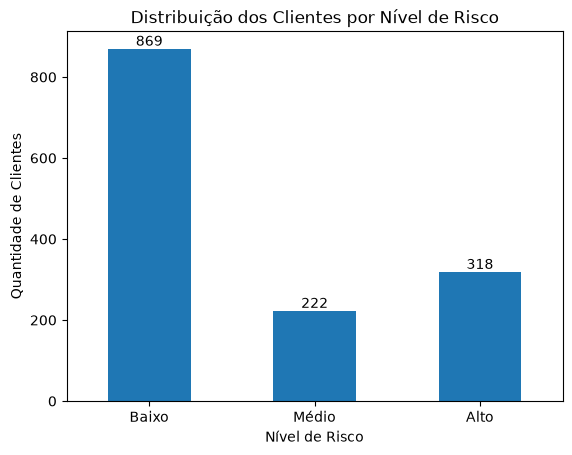

In [432]:
ordem_risco = ["Baixo", "Médio", "Alto"]

contagem_risco = (
    resultado["Nivel_Risco"]
    .value_counts()
    .reindex(ordem_risco)
)

ax = contagem_risco.plot(
    kind="bar",
    title="Distribuição dos Clientes por Nível de Risco",
    xlabel="Nível de Risco",
    ylabel="Quantidade de Clientes"
)

for barra in ax.patches:
    ax.annotate(
        int(barra.get_height()),
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.show()

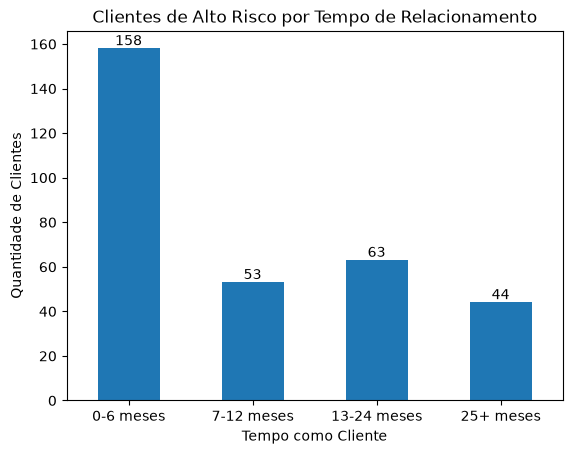

In [433]:
ordem_tenure = ["0-6 meses", "7-12 meses", "13-24 meses", "25+ meses"]

contagem_tenure = (
    clientes_alto_risco["Faixa_Tenure"]
    .value_counts()
    .reindex(ordem_tenure)
)

ax = contagem_tenure.plot(
    kind="bar",
    title="Clientes de Alto Risco por Tempo de Relacionamento",
    xlabel="Tempo como Cliente",
    ylabel="Quantidade de Clientes"
)

for barra in ax.patches:
    ax.annotate(
        int(barra.get_height()),
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.show()

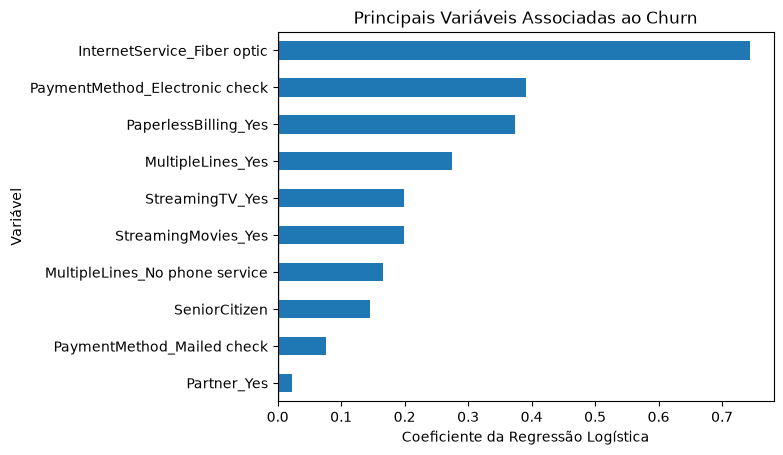

In [434]:
top_10_nomes = top_10.copy()

top_10_nomes.index = [
    X_train.columns[i]
    for i in top_10_nomes.index
]

ax = top_10_nomes.sort_values("Coeficiente")["Coeficiente"].plot(
    kind="barh",
    title="Principais Variáveis Associadas ao Churn",
    xlabel="Coeficiente da Regressão Logística",
    ylabel="Variável"
)

plt.axvline(0, linewidth=1)
plt.show()

In [435]:
# ============================================
# PIPELINE CORRIGIDA — PREPARAÇÃO DOS DADOS
# ============================================

import pandas as pd
import numpy as np

# 1. Fazer uma cópia do dataset original
df_modelo = df.copy()

# 2. Converter TotalCharges para número ANTES do encoding
df_modelo["TotalCharges"] = pd.to_numeric(
    df_modelo["TotalCharges"],
    errors="coerce"
)

# 3. Clientes novos possuem tenure = 0 e TotalCharges ausente.
#    Para esses casos, o valor acumulado é considerado 0.
df_modelo["TotalCharges"] = df_modelo["TotalCharges"].fillna(0)

# 4. Separar variável alvo e identificador
y = df_modelo["Churn"].map({"No": 0, "Yes": 1})

X = df_modelo.drop(
    columns=["Churn", "customerID"]
)

# 5. Conferir a preparação
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("\nValores ausentes em X:", X.isna().sum().sum())
print("Valores ausentes em y:", y.isna().sum())

print("\nTipo de TotalCharges:")
print(X["TotalCharges"].dtype)

print("\nExemplo dos dados:")
display(X.head())

Formato de X: (7043, 19)
Formato de y: (7043,)

Valores ausentes em X: 0
Valores ausentes em y: 0

Tipo de TotalCharges:
float64

Exemplo dos dados:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [436]:
# ============================================
# SEPARAÇÃO ENTRE TREINO E TESTE
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nProporção de churn no conjunto de treino:")
print(y_train.mean())

print("\nProporção de churn no conjunto de teste:")
print(y_test.mean())

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)

Proporção de churn no conjunto de treino:
0.2653532126375577

Proporção de churn no conjunto de teste:
0.2654364797728886


In [437]:
# Identificando as colunas categóricas
categorical_columns = X_train.select_dtypes(include=["object"]).columns

print("Colunas categóricas:")
print(categorical_columns.tolist())

Colunas categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\amand\AppData\Local\Temp\ipykernel_21116\3107407176.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include=["object"]).columns


In [438]:
from sklearn.preprocessing import OneHotEncoder

# Criando o encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)

# Aprendendo as categorias APENAS com os dados de treino
X_train_encoded = encoder.fit_transform(X_train[categorical_columns])

# Aplicando o mesmo encoder nos dados de teste
X_test_encoded = encoder.transform(X_test[categorical_columns])

print("Formato do treino após encoding:", X_train_encoded.shape)
print("Formato do teste após encoding:", X_test_encoded.shape)

Formato do treino após encoding: (5634, 26)
Formato do teste após encoding: (1409, 26)


In [439]:
# Selecionando as colunas numéricas
numeric_columns = X_train.select_dtypes(
    include=["number"]
).columns

print("Colunas numéricas:")
print(numeric_columns.tolist())

Colunas numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [440]:
import pandas as pd

# Dados numéricos
X_train_numeric = X_train[numeric_columns]
X_test_numeric = X_test[numeric_columns]

# Juntando dados numéricos + dados categóricos codificados
X_train_final = pd.concat(
    [
        X_train_numeric.reset_index(drop=True),
        pd.DataFrame(X_train_encoded)
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_numeric.reset_index(drop=True),
        pd.DataFrame(X_test_encoded)
    ],
    axis=1
)

print("Formato final do treino:", X_train_final.shape)
print("Formato final do teste:", X_test_final.shape)

Formato final do treino: (5634, 30)
Formato final do teste: (1409, 30)


In [441]:
from sklearn.linear_model import LogisticRegression

In [442]:
model = LogisticRegression(max_iter=1000)

In [443]:
# Convertendo todos os nomes das colunas para texto
X_train_final.columns = X_train_final.columns.astype(str)
X_test_final.columns = X_test_final.columns.astype(str)

print("Tipos dos nomes das colunas:")
print(set(type(col) for col in X_train_final.columns))

Tipos dos nomes das colunas:
{<class 'str'>}


In [444]:
model.fit(X_train_final, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


c:\Users\amand\OneDrive\Documentos\AI-Data-Analyst\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [445]:
from sklearn.preprocessing import StandardScaler

# Criando o scaler
scaler = StandardScaler()

# Aprendendo a escala apenas com os dados numéricos de treino
X_train_numeric_scaled = scaler.fit_transform(X_train[numeric_columns])

# Aplicando a mesma transformação aos dados numéricos de teste
X_test_numeric_scaled = scaler.transform(X_test[numeric_columns])

print("Formato dos dados numéricos escalados:")
print("Treino:", X_train_numeric_scaled.shape)
print("Teste:", X_test_numeric_scaled.shape)

Formato dos dados numéricos escalados:
Treino: (5634, 4)
Teste: (1409, 4)


In [446]:
# Transformando os dados numéricos escalados em DataFrame
X_train_numeric_scaled_df = pd.DataFrame(
    X_train_numeric_scaled,
    columns=numeric_columns
)

X_test_numeric_scaled_df = pd.DataFrame(
    X_test_numeric_scaled,
    columns=numeric_columns
)

# Juntando as variáveis numéricas escaladas com as categóricas codificadas
X_train_final = pd.concat(
    [
        X_train_numeric_scaled_df.reset_index(drop=True),
        pd.DataFrame(X_train_encoded)
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_numeric_scaled_df.reset_index(drop=True),
        pd.DataFrame(X_test_encoded)
    ],
    axis=1
)

# Garantindo que todos os nomes das colunas sejam strings
X_train_final.columns = X_train_final.columns.astype(str)
X_test_final.columns = X_test_final.columns.astype(str)

print("Formato final do treino:", X_train_final.shape)
print("Formato final do teste:", X_test_final.shape)

Formato final do treino: (5634, 30)
Formato final do teste: (1409, 30)


In [447]:
from sklearn.linear_model import LogisticRegression

# Criando uma nova Regressão Logística
model = LogisticRegression(max_iter=1000)

# Treinando o modelo com os dados escalados
model.fit(X_train_final, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [448]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_final, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [449]:
model.predict(X_test_final)

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [450]:
X_test_final

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,0,1,2,3,4,5,...,16,17,18,19,20,21,22,23,24,25
0,-0.441773,1.608483,1.629976,2.706828,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
1,2.263606,-0.996684,1.168725,-0.610260,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,-0.441773,0.346606,0.445324,0.400116,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3,-0.441773,-0.589626,0.440347,-0.364451,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.441773,1.608483,0.588013,1.588421,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,-0.441773,0.672252,0.738999,0.897615,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
1405,-0.441773,-0.182569,-1.480980,-0.794815,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
1406,-0.441773,-1.118801,-1.469365,-0.967873,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1407,-0.441773,0.957192,-1.500890,-0.547360,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [451]:
# Fazendo previsões no conjunto de teste
y_pred = model.predict(X_test_final)

print("Primeiras 20 previsões:")
print(y_pred[:20])

print("\nQuantidade de previsões:", len(y_pred))

Primeiras 20 previsões:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]

Quantidade de previsões: 1409


In [452]:
from sklearn.metrics import accuracy_score

# Comparando as previsões com os valores reais
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8069552874378992
Accuracy (%): 80.69552874378992


In [453]:
from sklearn.metrics import confusion_matrix

# Criando a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusão:")
print(cm)

Matriz de confusão:
[[927 108]
 [164 210]]


In [454]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [455]:
model.predict_proba(X_test_final)

array([[0.9541614 , 0.0458386 ],
       [0.31624177, 0.68375823],
       [0.93992762, 0.06007238],
       ...,
       [0.84579803, 0.15420197],
       [0.99555772, 0.00444228],
       [0.99357406, 0.00642594]], shape=(1409, 2))

In [456]:
# Obtendo as probabilidades para cada classe
y_proba = model.predict_proba(X_test_final)

# Pegando somente a probabilidade de churn
churn_probability = y_proba[:, 1]

print("Primeiras 20 probabilidades de churn:")
print(churn_probability[:20])

print("\nQuantidade de probabilidades:", len(churn_probability))

Primeiras 20 probabilidades de churn:
[0.0458386  0.68375823 0.06007238 0.39936455 0.02161438 0.60226845
 0.44714269 0.12890608 0.00289668 0.39605096 0.26579278 0.06283324
 0.12896399 0.68522568 0.12864749 0.05850219 0.03311818 0.63760253
 0.18089319 0.08563355]

Quantidade de probabilidades: 1409


In [457]:
import pandas as pd

# Criando os níveis de risco com base na probabilidade de churn
risk_level = pd.cut(
    churn_probability,
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Baixo", "Médio", "Alto"],
    include_lowest=True
)

# Criando uma tabela com as probabilidades e os níveis de risco
risk_analysis = pd.DataFrame({
    "Churn_Probability": churn_probability,
    "Risk_Level": risk_level
})

print(risk_analysis.head(20))

    Churn_Probability Risk_Level
0            0.045839      Baixo
1            0.683758       Alto
2            0.060072      Baixo
3            0.399365      Médio
4            0.021614      Baixo
5            0.602268       Alto
6            0.447143      Médio
7            0.128906      Baixo
8            0.002897      Baixo
9            0.396051      Médio
10           0.265793      Baixo
11           0.062833      Baixo
12           0.128964      Baixo
13           0.685226       Alto
14           0.128647      Baixo
15           0.058502      Baixo
16           0.033118      Baixo
17           0.637603       Alto
18           0.180893      Baixo
19           0.085634      Baixo


In [458]:
# Contando quantos clientes existem em cada nível de risco
risk_counts = risk_analysis["Risk_Level"].value_counts().reindex(
    ["Baixo", "Médio", "Alto"]
)

print("Quantidade de clientes por nível de risco:")
print(risk_counts)

print("\nPercentual de clientes por nível de risco:")
print((risk_counts / len(risk_analysis) * 100).round(2))

Quantidade de clientes por nível de risco:
Risk_Level
Baixo    866
Médio    334
Alto     209
Name: count, dtype: int64

Percentual de clientes por nível de risco:
Risk_Level
Baixo    61.46
Médio    23.70
Alto     14.83
Name: count, dtype: float64


In [459]:
# Recuperando os IDs dos clientes do conjunto de teste
customer_ids = df.loc[X_test.index, "customerID"].reset_index(drop=True)

# Adicionando os IDs à análise de risco
risk_analysis["customerID"] = customer_ids

# Reorganizando as colunas
risk_analysis = risk_analysis[
    ["customerID", "Churn_Probability", "Risk_Level"]
]

print(risk_analysis.head())

   customerID  Churn_Probability Risk_Level
0  4376-KFVRS           0.045839      Baixo
1  2754-SDJRD           0.683758       Alto
2  9917-KWRBE           0.060072      Baixo
3  0365-GXEZS           0.399365      Médio
4  9385-NXKDA           0.021614      Baixo


In [460]:
# Ordenando os clientes da maior para a menor probabilidade de churn
top_risk_customers = risk_analysis.sort_values(
    by="Churn_Probability",
    ascending=False
).head(10)

print("Top 10 clientes com maior risco de churn:")
print(top_risk_customers)

Top 10 clientes com maior risco de churn:
      customerID  Churn_Probability Risk_Level
1090  5178-LMXOP           0.855107       Alto
1221  0295-PPHDO           0.832080       Alto
1175  6861-XWTWQ           0.827946       Alto
1164  8884-ADFVN           0.823041       Alto
1109  1069-XAIEM           0.818811       Alto
627   9057-SIHCH           0.818052       Alto
647   6023-YEBUP           0.817840       Alto
1138  1400-MMYXY           0.817163       Alto
889   2545-EBUPK           0.817010       Alto
1355  6630-UJZMY           0.811211       Alto


In [461]:
# Obtendo os coeficientes aprendidos pelo modelo
coefficients = model.coef_[0]

# Criando uma tabela com as variáveis e seus coeficientes
coefficient_analysis = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Coefficient": coefficients
})

# Ordenando do maior coeficiente para o menor
coefficient_analysis = coefficient_analysis.sort_values(
    by="Coefficient",
    ascending=False
)

print("Variáveis mais associadas ao aumento do churn:")
print(coefficient_analysis.head(10))

print("\nVariáveis mais associadas à redução do churn:")
print(coefficient_analysis.tail(10))

Variáveis mais associadas ao aumento do churn:
          Feature  Coefficient
10              6     1.182298
3    TotalCharges     0.523110
28             24     0.383863
21             17     0.377500
23             19     0.376065
26             22     0.371284
9               5     0.362275
29             25     0.075442
0   SeniorCitizen     0.054651
17             13     0.035237

Variáveis mais associadas à redução do churn:
           Feature  Coefficient
12               8    -0.173381
6                2    -0.224945
8                4    -0.256658
19              15    -0.297591
13               9    -0.349623
2   MonthlyCharges    -0.470779
7                3    -0.505143
24              20    -0.686597
1           tenure    -1.250481
25              21    -1.326384


In [462]:
# Recuperando os nomes das variáveis criadas pelo One-Hot Encoding
encoded_feature_names = encoder.get_feature_names_out(categorical_columns)

# Juntando nomes das variáveis numéricas + categóricas
feature_names = list(numeric_columns) + list(encoded_feature_names)

# Criando a tabela de coeficientes
coefficient_analysis = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

# Ordenando pelos maiores coeficientes
coefficient_analysis = coefficient_analysis.sort_values(
    by="Coefficient",
    ascending=False
)

print("Maiores associações com aumento do churn:")
print(coefficient_analysis.head(10))

print("\nMaiores associações com redução do churn:")
print(coefficient_analysis.tail(10))

Maiores associações com aumento do churn:
                           Feature  Coefficient
10     InternetService_Fiber optic     1.182298
3                     TotalCharges     0.523110
28  PaymentMethod_Electronic check     0.383863
21                 StreamingTV_Yes     0.377500
23             StreamingMovies_Yes     0.376065
26            PaperlessBilling_Yes     0.371284
9                MultipleLines_Yes     0.362275
29      PaymentMethod_Mailed check     0.075442
0                    SeniorCitizen     0.054651
17            DeviceProtection_Yes     0.035237

Maiores associações com redução do churn:
                               Feature  Coefficient
12  OnlineSecurity_No internet service    -0.173381
6                       Dependents_Yes    -0.224945
8       MultipleLines_No phone service    -0.256658
19                     TechSupport_Yes    -0.297591
13                  OnlineSecurity_Yes    -0.349623
2                       MonthlyCharges    -0.470779
7                     P

In [463]:
from sklearn.metrics import roc_auc_score

# Calculando o ROC-AUC usando as probabilidades de churn
roc_auc = roc_auc_score(y_test, churn_probability)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8421710713270816


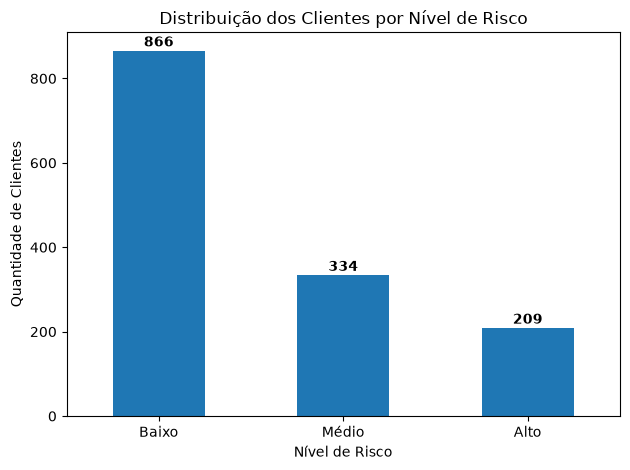

In [464]:
import matplotlib.pyplot as plt

ax = risk_counts.plot(kind="bar")

plt.title("Distribuição dos Clientes por Nível de Risco")
plt.xlabel("Nível de Risco")
plt.ylabel("Quantidade de Clientes")
plt.xticks(rotation=0)

# Adicionando os valores acima das barras
for i, valor in enumerate(risk_counts):
    ax.text(
        i,
        valor + 10,
        str(valor),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

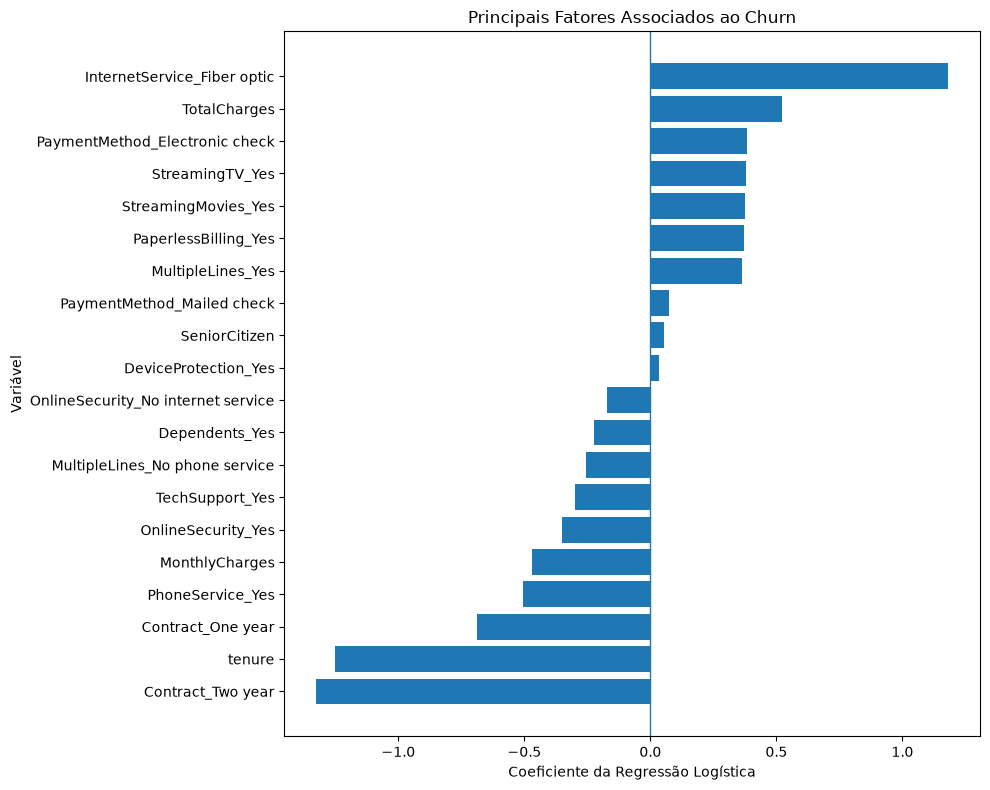

In [465]:
import matplotlib.pyplot as plt

# Selecionando as 10 maiores e 10 menores associações
top_positive = coefficient_analysis.head(10)
top_negative = coefficient_analysis.tail(10)

# Juntando as duas partes
top_coefficients = pd.concat([top_positive, top_negative])

# Ordenando para facilitar a visualização
top_coefficients = top_coefficients.sort_values(
    by="Coefficient"
)

# Criando o gráfico
plt.figure(figsize=(10, 8))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.axvline(x=0, linewidth=1)

plt.title("Principais Fatores Associados ao Churn")
plt.xlabel("Coeficiente da Regressão Logística")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

In [466]:
# Obtendo os coeficientes aprendidos pelo modelo
coefficients = model.coef_[0]

# Criando uma tabela com as variáveis e seus coeficientes
coefficient_analysis = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Coefficient": coefficients
})

# Ordenando do maior coeficiente para o menor
coefficient_analysis = coefficient_analysis.sort_values(
    by="Coefficient",
    ascending=False
)

print("Variáveis mais associadas ao aumento do churn:")
print(coefficient_analysis.head(10))

print("\nVariáveis mais associadas à redução do churn:")
print(coefficient_analysis.tail(10))

Variáveis mais associadas ao aumento do churn:
          Feature  Coefficient
10              6     1.182298
3    TotalCharges     0.523110
28             24     0.383863
21             17     0.377500
23             19     0.376065
26             22     0.371284
9               5     0.362275
29             25     0.075442
0   SeniorCitizen     0.054651
17             13     0.035237

Variáveis mais associadas à redução do churn:
           Feature  Coefficient
12               8    -0.173381
6                2    -0.224945
8                4    -0.256658
19              15    -0.297591
13               9    -0.349623
2   MonthlyCharges    -0.470779
7                3    -0.505143
24              20    -0.686597
1           tenure    -1.250481
25              21    -1.326384


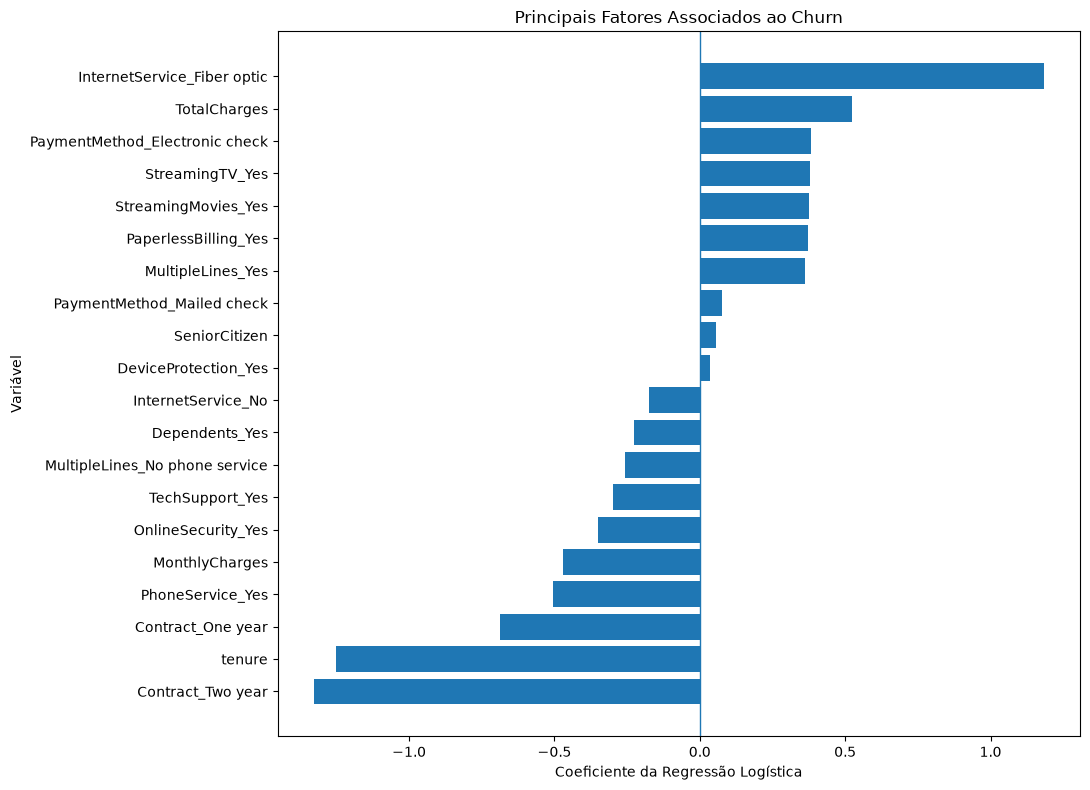

In [467]:
# Recuperando os nomes das features categóricas criadas pelo encoder
encoded_feature_names = encoder.get_feature_names_out(categorical_columns)

# Juntando as 4 variáveis numéricas + 26 variáveis categóricas
feature_names = list(numeric_columns) + list(encoded_feature_names)

# Criando novamente a tabela de coeficientes com os nomes corretos
coefficient_analysis = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

# Selecionando as 10 maiores associações positivas e negativas
top_positive = coefficient_analysis.nlargest(10, "Coefficient")
top_negative = coefficient_analysis.nsmallest(10, "Coefficient")

# Juntando os dois grupos
top_coefficients = pd.concat([
    top_negative,
    top_positive
])

# Ordenando para o gráfico ficar organizado
top_coefficients = top_coefficients.sort_values(
    by="Coefficient"
)

# Criando o gráfico
plt.figure(figsize=(11, 8))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

# Linha central no zero
plt.axvline(x=0, linewidth=1)

plt.title("Principais Fatores Associados ao Churn")
plt.xlabel("Coeficiente da Regressão Logística")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

In [468]:
# ============================================
# ENCODING DAS VARIÁVEIS CATEGÓRICAS
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Colunas numéricas
colunas_numericas = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Colunas categóricas
colunas_categoricas = [
    coluna for coluna in X_train.columns
    if coluna not in colunas_numericas
]

# Criar o transformador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", colunas_numericas),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), colunas_categoricas)
    ]
)

# Aprender as categorias SOMENTE no treino
X_train_encoded = preprocessor.fit_transform(X_train)

# Aplicar a mesma transformação no teste
X_test_encoded = preprocessor.transform(X_test)

print("Formato X_train_encoded:", X_train_encoded.shape)
print("Formato X_test_encoded:", X_test_encoded.shape)

Formato X_train_encoded: (5634, 30)
Formato X_test_encoded: (1409, 30)


In [469]:
# ============================================
# TREINAMENTO DA REGRESSÃO LOGÍSTICA
# ============================================

from sklearn.linear_model import LogisticRegression

# Criar o modelo
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Treinar o modelo
model.fit(X_train_encoded, y_train)

print("Modelo treinado com sucesso!")
print("Quantidade de coeficientes:", len(model.coef_[0]))

Modelo treinado com sucesso!
Quantidade de coeficientes: 30


c:\Users\amand\OneDrive\Documentos\AI-Data-Analyst\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [470]:
# ============================================
# ENCODING + ESCALONAMENTO
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Variáveis numéricas
colunas_numericas = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Variáveis categóricas
colunas_categoricas = [
    coluna for coluna in X_train.columns
    if coluna not in colunas_numericas
]

# Preparar as transformações
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ), colunas_categoricas)
    ]
)

# Aprender SOMENTE com os dados de treino
X_train_encoded = preprocessor.fit_transform(X_train)

# Aplicar a mesma transformação no teste
X_test_encoded = preprocessor.transform(X_test)

print("Formato X_train_encoded:", X_train_encoded.shape)
print("Formato X_test_encoded:", X_test_encoded.shape)
print("Encoding e escalonamento concluídos!")

Formato X_train_encoded: (5634, 30)
Formato X_test_encoded: (1409, 30)
Encoding e escalonamento concluídos!


In [471]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_encoded, y_train)

print("Modelo treinado com sucesso!")
print("Quantidade de coeficientes:", len(model.coef_[0]))

Modelo treinado com sucesso!
Quantidade de coeficientes: 30


In [472]:
# ============================================
# AVALIAÇÃO DO MODELO
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test_encoded)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== MÉTRICAS DO MODELO =====")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\n===== MATRIZ DE CONFUSÃO =====")
print(confusion_matrix(y_test, y_pred))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Não Churn", "Churn"]
))

===== MÉTRICAS DO MODELO =====
Accuracy:  0.8070
Precision: 0.6604
Recall:    0.5615
F1-score:  0.6069

===== MATRIZ DE CONFUSÃO =====
[[927 108]
 [164 210]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   Não Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



===== ROC-AUC =====
ROC-AUC: 0.8422


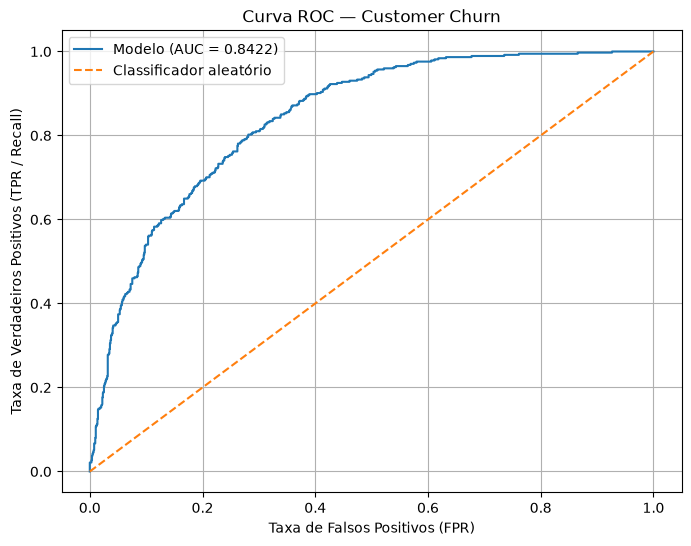

In [473]:
# ============================================
# ROC-AUC E CURVA ROC
# ============================================

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probabilidade prevista para a classe Churn
y_prob = model.predict_proba(X_test_encoded)[:, 1]

# Calcular ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("===== ROC-AUC =====")
print(f"ROC-AUC: {roc_auc:.4f}")

# Calcular pontos da curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plotar curva ROC
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Modelo (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR / Recall)")
plt.title("Curva ROC — Customer Churn")
plt.legend()
plt.grid(True)

plt.show()

In [474]:
# ============================================
# ANÁLISE DE THRESHOLD
# ============================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Probabilidades de churn
y_prob = model.predict_proba(X_test_encoded)[:, 1]

# Thresholds que queremos testar
thresholds_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

resultados = []

for threshold in thresholds_test:

    # Transformar probabilidade em classe
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    resultados.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

# Criar tabela
threshold_results = pd.DataFrame(resultados)

print("===== ANÁLISE DE THRESHOLD =====")
print(threshold_results.round(4))

===== ANÁLISE DE THRESHOLD =====
   Threshold  Precision  Recall  F1-score
0       0.30     0.5193  0.7540    0.6150
1       0.35     0.5441  0.7086    0.6156
2       0.40     0.5708  0.6684    0.6158
3       0.45     0.6005  0.6150    0.6077
4       0.50     0.6604  0.5615    0.6069
5       0.55     0.6772  0.4599    0.5478
6       0.60     0.7177  0.4011    0.5146


In [475]:
# ============================================
# QUANTIDADE DE CLIENTES SINALIZADOS POR THRESHOLD
# ============================================

import pandas as pd

thresholds_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

resultados_volume = []

total_clientes = len(y_test)

for threshold in thresholds_test:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    clientes_churn_previsto = y_pred_threshold.sum()

    percentual_base = (
        clientes_churn_previsto / total_clientes
    ) * 100

    resultados_volume.append({
        "Threshold": threshold,
        "Clientes sinalizados": clientes_churn_previsto,
        "% da base sinalizada": percentual_base
    })

volume_results = pd.DataFrame(resultados_volume)

print("===== VOLUME DE CLIENTES SINALIZADOS =====")
print(volume_results.round(2))

===== VOLUME DE CLIENTES SINALIZADOS =====
   Threshold  Clientes sinalizados  % da base sinalizada
0       0.30                   543                 38.54
1       0.35                   487                 34.56
2       0.40                   438                 31.09
3       0.45                   383                 27.18
4       0.50                   318                 22.57
5       0.55                   254                 18.03
6       0.60                   209                 14.83


In [476]:
# ============================================
# NOMES DAS FEATURES APÓS O ENCODING
# ============================================

feature_names = preprocessor.get_feature_names_out()

print("Quantidade de features:", len(feature_names))
print("\nPrimeiras features:")
print(feature_names[:20])

Quantidade de features: 30

Primeiras features:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Male' 'cat__Partner_Yes'
 'cat__Dependents_Yes' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes']


In [477]:
# ============================================
# IMPORTÂNCIA DAS FEATURES — REGRESSÃO LOGÍSTICA
# ============================================

import pandas as pd

# Recuperar coeficientes do modelo
coefficients = model.coef_[0]

# Criar tabela com nomes e coeficientes
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Ordenar pelos coeficientes
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("===== RANKING DOS COEFICIENTES =====")
print(feature_importance.to_string(index=False))

===== RANKING DOS COEFICIENTES =====
                                   Feature  Coefficient
          cat__InternetService_Fiber optic     1.182298
                         num__TotalCharges     0.523110
       cat__PaymentMethod_Electronic check     0.383863
                      cat__StreamingTV_Yes     0.377500
                  cat__StreamingMovies_Yes     0.376065
                 cat__PaperlessBilling_Yes     0.371284
                    cat__MultipleLines_Yes     0.362275
           cat__PaymentMethod_Mailed check     0.075442
                        num__SeniorCitizen     0.054651
                 cat__DeviceProtection_Yes     0.035237
                          cat__gender_Male     0.022561
                          cat__Partner_Yes     0.021550
cat__PaymentMethod_Credit card (automatic)    -0.030080
                     cat__OnlineBackup_Yes    -0.097690
     cat__OnlineBackup_No internet service    -0.173381
      cat__StreamingTV_No internet service    -0.173381
      cat__

In [478]:
# ============================================
# FATORES ASSOCIADOS AO CHURN
# ============================================

positive_features = (
    feature_importance[
        feature_importance["Coefficient"] > 0
    ]
    .sort_values("Coefficient", ascending=False)
)

print("===== FATORES ASSOCIADOS A MAIOR CHURN =====")
print(positive_features.to_string(index=False))


# ============================================
# FATORES ASSOCIADOS A MENOR CHURN
# ============================================

negative_features = (
    feature_importance[
        feature_importance["Coefficient"] < 0
    ]
    .sort_values("Coefficient", ascending=True)
)

print("\n===== FATORES ASSOCIADOS A MENOR CHURN =====")
print(negative_features.to_string(index=False))

===== FATORES ASSOCIADOS A MAIOR CHURN =====
                            Feature  Coefficient
   cat__InternetService_Fiber optic     1.182298
                  num__TotalCharges     0.523110
cat__PaymentMethod_Electronic check     0.383863
               cat__StreamingTV_Yes     0.377500
           cat__StreamingMovies_Yes     0.376065
          cat__PaperlessBilling_Yes     0.371284
             cat__MultipleLines_Yes     0.362275
    cat__PaymentMethod_Mailed check     0.075442
                 num__SeniorCitizen     0.054651
          cat__DeviceProtection_Yes     0.035237
                   cat__gender_Male     0.022561
                   cat__Partner_Yes     0.021550

===== FATORES ASSOCIADOS A MENOR CHURN =====
                                   Feature  Coefficient
                    cat__Contract_Two year    -1.326384
                               num__tenure    -1.250481
                    cat__Contract_One year    -0.686597
                     cat__PhoneService_Yes    -0

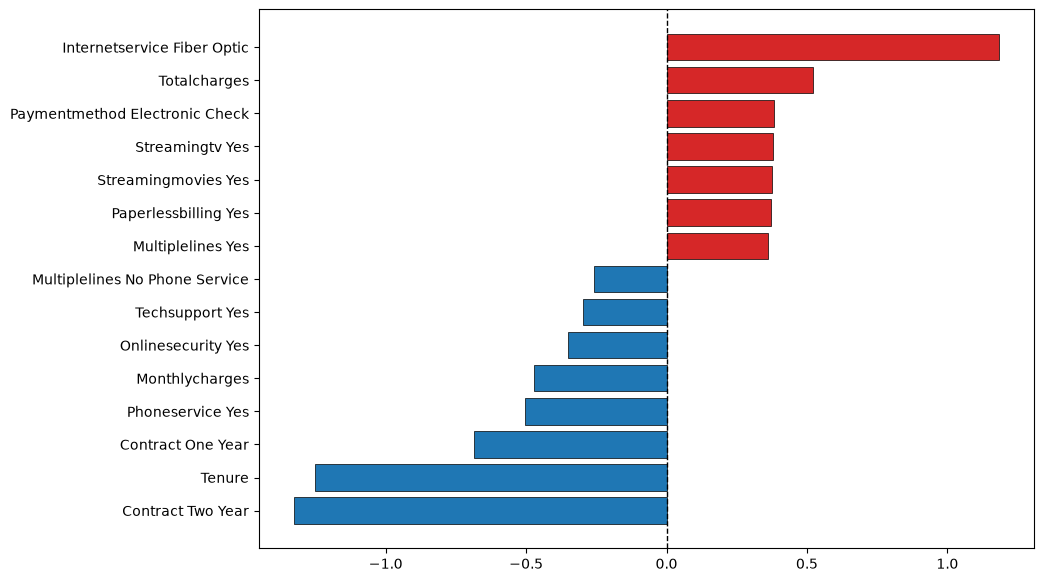

In [479]:
# ============================================
# GRÁFICO DOS PRINCIPAIS COEFICIENTES
# ============================================
import pandas as pd
import matplotlib.pyplot as plt

# Selecionar os 15 coeficientes de maior magnitude
top_features = (
    feature_importance
    .assign(AbsCoefficient=lambda x: x["Coefficient"].abs())
    .sort_values("AbsCoefficient", ascending=False)
    .head(15)
    .sort_values("Coefficient")
    .reset_index(drop=True)
)

# Criar nomes mais legíveis
top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

# Definir cores: vermelho = aumenta risco de churn, azul = reduz risco
colors = top_features["Coefficient"].apply(
    lambda x: "#d62728" if x > 0 else "#1f77b4"
)

# Criar gráfico
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_features["Feature"],
    top_features["Coefficient"],
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

# Linha de referência em zero
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)

# Adicionar rótulos com o valor de cada coeficiente
for bar in bars:
    width = bar.get_width()

In [482]:
import sys

print("Python usado pelo Jupyter:")
print(sys.executable)

print("\nVersão:")
print(sys.version)

Python usado pelo Jupyter:
c:\Users\amand\OneDrive\Documentos\AI-Data-Analyst\.venv\Scripts\python.exe

Versão:
3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]


In [483]:
import sys
!{sys.executable} -m pip install statsmodels

  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   ----------

In [484]:
import statsmodels

print("statsmodels instalado com sucesso!")
print("Versão:", statsmodels.__version__)

statsmodels instalado com sucesso!
Versão: 0.14.6


In [485]:
# ============================================
# ANÁLISE DE MULTICOLINEARIDADE — VIF
# ============================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Selecionar as variáveis numéricas
vif_data = X_train[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].copy()

# Calcular VIF
vif_results = pd.DataFrame()

vif_results["Feature"] = vif_data.columns

vif_results["VIF"] = [
    variance_inflation_factor(
        vif_data.values,
        i
    )
    for i in range(vif_data.shape[1])
]

print("===== VIF — MULTICOLINEARIDADE =====")
print(vif_results.round(2))

===== VIF — MULTICOLINEARIDADE =====
          Feature   VIF
0          tenure  6.47
1  MonthlyCharges  3.39
2    TotalCharges  8.21


In [486]:
# ============================================
# MODELO ALTERNATIVO — SEM TotalCharges
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Remover TotalCharges
X_train_no_total = X_train.drop(columns=["TotalCharges"])
X_test_no_total = X_test.drop(columns=["TotalCharges"])

# Identificar tipos de variáveis
numeric_features_no_total = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges"
]

categorical_features_no_total = [
    col for col in X_train_no_total.columns
    if col not in numeric_features_no_total
]

# Novo pré-processador
preprocessor_no_total = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_no_total
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features_no_total
        )
    ]
)

# Novo modelo
model_no_total = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_total),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

# Treinar
model_no_total.fit(X_train_no_total, y_train)

print("Modelo alternativo treinado com sucesso!")

print(
    "Features utilizadas:",
    model_no_total.named_steps[
        "preprocessor"
    ].get_feature_names_out().shape[0]
)

Modelo alternativo treinado com sucesso!
Features utilizadas: 29


In [487]:
# ============================================
# AVALIAÇÃO — MODELO SEM TotalCharges
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Probabilidades
y_prob_no_total = model_no_total.predict_proba(
    X_test_no_total
)[:, 1]

# Previsão usando threshold padrão 0.50
y_pred_no_total = (
    y_prob_no_total >= 0.50
).astype(int)

print("===== MODELO SEM TotalCharges =====")

print(
    f"Accuracy:  {accuracy_score(y_test, y_pred_no_total):.4f}"
)

print(
    f"Precision: {precision_score(y_test, y_pred_no_total):.4f}"
)

print(
    f"Recall:    {recall_score(y_test, y_pred_no_total):.4f}"
)

print(
    f"F1-score:  {f1_score(y_test, y_pred_no_total):.4f}"
)

print(
    f"ROC-AUC:   {roc_auc_score(y_test, y_prob_no_total):.4f}"
)

print("\n===== MATRIZ DE CONFUSÃO =====")

print(
    confusion_matrix(
        y_test,
        y_pred_no_total
    )
)

===== MODELO SEM TotalCharges =====
Accuracy:  0.7970
Precision: 0.6375
Recall:    0.5455
F1-score:  0.5879
ROC-AUC:   0.8393

===== MATRIZ DE CONFUSÃO =====
[[919 116]
 [170 204]]


In [488]:
# ============================================
# CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS
# ============================================

correlation_matrix = X_train[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].corr()

print("===== MATRIZ DE CORRELAÇÃO =====")
print(correlation_matrix.round(3))

===== MATRIZ DE CORRELAÇÃO =====
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.257         0.830
MonthlyCharges   0.257           1.000         0.654
TotalCharges     0.830           0.654         1.000


In [490]:
# ============================================
# INSPECIONAR O PREPROCESSADOR
# ============================================

print("===== TRANSFORMERS DO PREPROCESSADOR =====")

for name, transformer, columns in preprocessor.transformers_:
    print(f"\nNome: {name}")
    print(f"Transformador: {transformer}")
    print(f"Quantidade de colunas: {len(columns)}")
    print(f"Colunas: {list(columns)}")

===== TRANSFORMERS DO PREPROCESSADOR =====

Nome: num
Transformador: StandardScaler()
Quantidade de colunas: 4
Colunas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Nome: cat
Transformador: OneHotEncoder(drop='first', handle_unknown='ignore')
Quantidade de colunas: 15
Colunas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [491]:
# ============================================
# INSPECIONAR O PREPROCESSADOR
# ============================================

print("===== TRANSFORMERS DO PREPROCESSADOR =====")

for name, transformer, columns in preprocessor.transformers_:
    print(f"\nNome: {name}")
    print(f"Transformador: {transformer}")
    print(f"Quantidade de colunas: {len(columns)}")
    print(f"Colunas: {list(columns)}")

===== TRANSFORMERS DO PREPROCESSADOR =====

Nome: num
Transformador: StandardScaler()
Quantidade de colunas: 4
Colunas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Nome: cat
Transformador: OneHotEncoder(drop='first', handle_unknown='ignore')
Quantidade de colunas: 15
Colunas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [492]:
# ============================================
# CATEGORIAS DO ONE-HOT ENCODER
# ============================================

encoder = preprocessor.named_transformers_["cat"]

categorical_columns = preprocessor.transformers_[1][2]

print("===== CATEGORIAS DO ENCODER =====")

for feature, categories in zip(
    categorical_columns,
    encoder.categories_
):
    print(f"\n{feature}:")
    print(list(categories))

===== CATEGORIAS DO ENCODER =====

gender:
['Female', 'Male']

Partner:
['No', 'Yes']

Dependents:
['No', 'Yes']

PhoneService:
['No', 'Yes']

MultipleLines:
['No', 'No phone service', 'Yes']

InternetService:
['DSL', 'Fiber optic', 'No']

OnlineSecurity:
['No', 'No internet service', 'Yes']

OnlineBackup:
['No', 'No internet service', 'Yes']

DeviceProtection:
['No', 'No internet service', 'Yes']

TechSupport:
['No', 'No internet service', 'Yes']

StreamingTV:
['No', 'No internet service', 'Yes']

StreamingMovies:
['No', 'No internet service', 'Yes']

Contract:
['Month-to-month', 'One year', 'Two year']

PaperlessBilling:
['No', 'Yes']

PaymentMethod:
['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


In [493]:
# ============================================================
# VALIDAÇÃO FINAL DO MODELO
# Threshold + PR-AUC + Avaliação Final
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. SEPARAR TREINO E VALIDAÇÃO
# ============================================================

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("===== DIVISÃO DOS DADOS =====")
print(f"Treino:     {X_train_model.shape}")
print(f"Validação:  {X_val.shape}")
print(f"Teste:      {X_test.shape}")


# ============================================================
# 2. TREINAR NOVAMENTE O MODELO
# ============================================================

model_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

model_final.fit(
    X_train_model,
    y_train_model
)

print("\nModelo treinado com sucesso!")


# ============================================================
# 3. PROBABILIDADES NA VALIDAÇÃO
# ============================================================

y_val_prob = model_final.predict_proba(X_val)[:, 1]

roc_auc_val = roc_auc_score(
    y_val,
    y_val_prob
)

pr_auc_val = average_precision_score(
    y_val,
    y_val_prob
)

print("\n===== MÉTRICAS NA VALIDAÇÃO =====")
print(f"ROC-AUC: {roc_auc_val:.4f}")
print(f"PR-AUC:  {pr_auc_val:.4f}")


# ============================================================
# 4. TESTAR THRESHOLDS
# ============================================================

thresholds = np.arange(
    0.20,
    0.61,
    0.01
)

threshold_results = []

for threshold in thresholds:

    y_val_pred = (
        y_val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    customers_flagged = y_val_pred.sum()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Clientes sinalizados": customers_flagged,
        "% da validação": (
            customers_flagged / len(y_val)
        ) * 100
    })


threshold_df = pd.DataFrame(
    threshold_results
)


# ============================================================
# 5. ENCONTRAR MELHOR THRESHOLD
# ============================================================

best_row = threshold_df.loc[
    threshold_df["F1-score"].idxmax()
]

best_threshold = best_row["Threshold"]


print("\n===== MELHOR THRESHOLD NA VALIDAÇÃO =====")

print(
    threshold_df[
        threshold_df["F1-score"]
        == threshold_df["F1-score"].max()
    ].round(4)
)

print(
    f"\nThreshold escolhido: {best_threshold:.2f}"
)


# ============================================================
# 6. AVALIAÇÃO FINAL NO TESTE
# ============================================================

# Probabilidades do teste
y_test_prob_final = model_final.predict_proba(
    X_test
)[:, 1]


# Aplicar SOMENTE agora o threshold escolhido
y_test_pred_final = (
    y_test_prob_final >= best_threshold
).astype(int)


# ============================================================
# 7. MÉTRICAS FINAIS
# ============================================================

accuracy_final = accuracy_score(
    y_test,
    y_test_pred_final
)

precision_final = precision_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

recall_final = recall_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

f1_final = f1_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

roc_auc_final = roc_auc_score(
    y_test,
    y_test_prob_final
)

pr_auc_final = average_precision_score(
    y_test,
    y_test_prob_final
)


print("\n")
print("================================================")
print("          AVALIAÇÃO FINAL DO MODELO")
print("================================================")

print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy:  {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall:    {recall_final:.4f}")
print(f"F1-score:  {f1_final:.4f}")
print(f"ROC-AUC:   {roc_auc_final:.4f}")
print(f"PR-AUC:    {pr_auc_final:.4f}")


# ============================================================
# 8. MATRIZ DE CONFUSÃO
# ============================================================

print("\n===== MATRIZ DE CONFUSÃO =====")

print(
    confusion_matrix(
        y_test,
        y_test_pred_final
    )
)


# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_test_pred_final,
        target_names=[
            "Não Churn",
            "Churn"
        ],
        zero_division=0
    )
)


# ============================================================
# 10. VOLUME DE CLIENTES SINALIZADOS
# ============================================================

clientes_sinalizados = (
    y_test_pred_final.sum()
)

percentual_sinalizado = (
    clientes_sinalizados /
    len(y_test)
) * 100


print("\n===== VOLUME DE CLIENTES SINALIZADOS =====")

print(
    f"Clientes sinalizados: "
    f"{clientes_sinalizados}"
)

print(
    f"% da base de teste sinalizada: "
    f"{percentual_sinalizado:.2f}%"
)

===== DIVISÃO DOS DADOS =====
Treino:     (4507, 19)
Validação:  (1127, 19)
Teste:      (1409, 19)

Modelo treinado com sucesso!

===== MÉTRICAS NA VALIDAÇÃO =====
ROC-AUC: 0.8482
PR-AUC:  0.6664

===== MELHOR THRESHOLD NA VALIDAÇÃO =====
    Threshold  Precision  Recall  F1-score  Clientes sinalizados  \
18       0.38     0.6077   0.689    0.6458                   339   

    % da validação  
18         30.0799  

Threshold escolhido: 0.38


          AVALIAÇÃO FINAL DO MODELO
Threshold: 0.38
Accuracy:  0.7750
Precision: 0.5624
Recall:    0.6872
F1-score:  0.6185
ROC-AUC:   0.8425
PR-AUC:    0.6330

===== MATRIZ DE CONFUSÃO =====
[[835 200]
 [117 257]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   Não Churn       0.88      0.81      0.84      1035
       Churn       0.56      0.69      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.

In [494]:
print("================================================")
print("          AVALIAÇÃO FINAL DO MODELO")
print("================================================")

print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy:  {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall:    {recall_final:.4f}")
print(f"F1-score:  {f1_final:.4f}")
print(f"ROC-AUC:   {roc_auc_final:.4f}")
print(f"PR-AUC:    {pr_auc_final:.4f}")

print("\n===== MATRIZ DE CONFUSÃO =====")
print(confusion_matrix(y_test, y_test_pred_final))

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_test_pred_final,
        target_names=["Não Churn", "Churn"],
        zero_division=0
    )
)

print("\n===== VOLUME DE CLIENTES SINALIZADOS =====")
print(f"Clientes sinalizados: {y_test_pred_final.sum()}")
print(
    f"% da base de teste sinalizada: "
    f"{(y_test_pred_final.sum() / len(y_test)) * 100:.2f}%"
)

          AVALIAÇÃO FINAL DO MODELO
Threshold: 0.38
Accuracy:  0.7750
Precision: 0.5624
Recall:    0.6872
F1-score:  0.6185
ROC-AUC:   0.8425
PR-AUC:    0.6330

===== MATRIZ DE CONFUSÃO =====
[[835 200]
 [117 257]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   Não Churn       0.88      0.81      0.84      1035
       Churn       0.56      0.69      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.78      0.78      1409


===== VOLUME DE CLIENTES SINALIZADOS =====
Clientes sinalizados: 457
% da base de teste sinalizada: 32.43%


In [495]:
# ============================================
# AUDITORIA — FIT DO PREPROCESSADOR
# ============================================

print("===== AUDITORIA DO PREPROCESSADOR =====")

print("Preprocessor utilizado no modelo final:")
print(model_final.named_steps["preprocessor"])

print("\n===== DATASET USADO NO FIT =====")

# Verificar o número de linhas usado no treinamento
print(f"Linhas do treino interno: {len(X_train_model)}")
print(f"Linhas da validação:      {len(X_val)}")
print(f"Linhas do teste:          {len(X_test)}")

print("\n===== STATUS =====")

print(
    "O preprocessor está dentro do Pipeline e foi "
    "ajustado durante o model_final.fit(X_train_model, y_train_model)."
)

print("\nTreino usado no fit do modelo:")
print(X_train_model.shape)

print("\nValidação NÃO usada no fit:")
print(X_val.shape)

print("\nTeste NÃO usado no fit:")
print(X_test.shape)

===== AUDITORIA DO PREPROCESSADOR =====
Preprocessor utilizado no modelo final:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

===== DATASET USADO NO FIT =====
Linhas do treino interno: 4507
Linhas da va

In [496]:
# ============================================================
# ABLATION — REMOVER CATEGORIAS "NO INTERNET SERVICE"
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ============================================================
# 1. DEFINIR COLUNAS
# ============================================================

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# ============================================================
# 2. REMOVER AS 6 VARIÁVEIS REDUNDANTES
# ============================================================

no_internet_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

categorical_features_reduced = [
    feature
    for feature in categorical_features
    if feature not in no_internet_features
]

print("===== ABLATION NO INTERNET SERVICE =====")

print("\nVariáveis removidas:")
for feature in no_internet_features:
    print("-", feature)

print("\nVariáveis categóricas restantes:")
print(categorical_features_reduced)


# ============================================================
# 3. NOVO PREPROCESSADOR
# ============================================================

preprocessor_reduced = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features_reduced
        )
    ]
)


# ============================================================
# 4. NOVO MODELO
# ============================================================

model_reduced = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_reduced
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)


# ============================================================
# 5. TREINAR SOMENTE NO TREINO INTERNO
# ============================================================

model_reduced.fit(
    X_train_model,
    y_train_model
)

print("\nModelo reduzido treinado com sucesso!")


# ============================================================
# 6. PROBABILIDADES NA VALIDAÇÃO
# ============================================================

y_val_prob_reduced = model_reduced.predict_proba(
    X_val
)[:, 1]

roc_auc_val_reduced = roc_auc_score(
    y_val,
    y_val_prob_reduced
)

pr_auc_val_reduced = average_precision_score(
    y_val,
    y_val_prob_reduced
)


# ============================================================
# 7. APLICAR O MESMO THRESHOLD 0.38
# ============================================================

y_val_pred_reduced = (
    y_val_prob_reduced >= best_threshold
).astype(int)

accuracy_val_reduced = accuracy_score(
    y_val,
    y_val_pred_reduced
)

precision_val_reduced = precision_score(
    y_val,
    y_val_pred_reduced,
    zero_division=0
)

recall_val_reduced = recall_score(
    y_val,
    y_val_pred_reduced,
    zero_division=0
)

f1_val_reduced = f1_score(
    y_val,
    y_val_pred_reduced,
    zero_division=0
)


# ============================================================
# 8. RESULTADOS NA VALIDAÇÃO
# ============================================================

print("\n===== MODELO REDUZIDO — VALIDAÇÃO =====")

print(f"Accuracy:  {accuracy_val_reduced:.4f}")
print(f"Precision: {precision_val_reduced:.4f}")
print(f"Recall:    {recall_val_reduced:.4f}")
print(f"F1-score:  {f1_val_reduced:.4f}")
print(f"ROC-AUC:   {roc_auc_val_reduced:.4f}")
print(f"PR-AUC:    {pr_auc_val_reduced:.4f}")


# ============================================================
# 9. COMPARAÇÃO COM MODELO COMPLETO
# ============================================================

comparison = pd.DataFrame({
    "Modelo": [
        "Completo",
        "Sem No internet service"
    ],
    "ROC-AUC": [
        roc_auc_val,
        roc_auc_val_reduced
    ],
    "PR-AUC": [
        pr_auc_val,
        pr_auc_val_reduced
    ],
    "Precision": [
        best_row["Precision"],
        precision_val_reduced
    ],
    "Recall": [
        best_row["Recall"],
        recall_val_reduced
    ],
    "F1-score": [
        best_row["F1-score"],
        f1_val_reduced
    ]
})

print("\n===== COMPARAÇÃO =====")

print(
    comparison.round(4).to_string(index=False)
)

===== ABLATION NO INTERNET SERVICE =====

Variáveis removidas:
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies

Variáveis categóricas restantes:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Modelo reduzido treinado com sucesso!

===== MODELO REDUZIDO — VALIDAÇÃO =====
Accuracy:  0.7941
Precision: 0.6006
Recall:    0.6689
F1-score:  0.6329
ROC-AUC:   0.8467
PR-AUC:    0.6640

===== COMPARAÇÃO =====
                 Modelo  ROC-AUC  PR-AUC  Precision  Recall  F1-score
               Completo   0.8482  0.6664     0.6077  0.6890    0.6458
Sem No internet service   0.8467  0.6640     0.6006  0.6689    0.6329


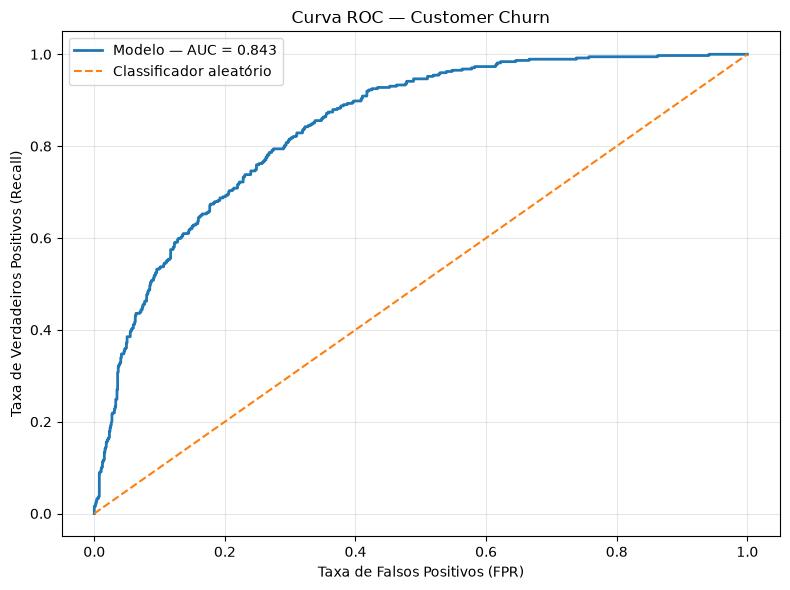

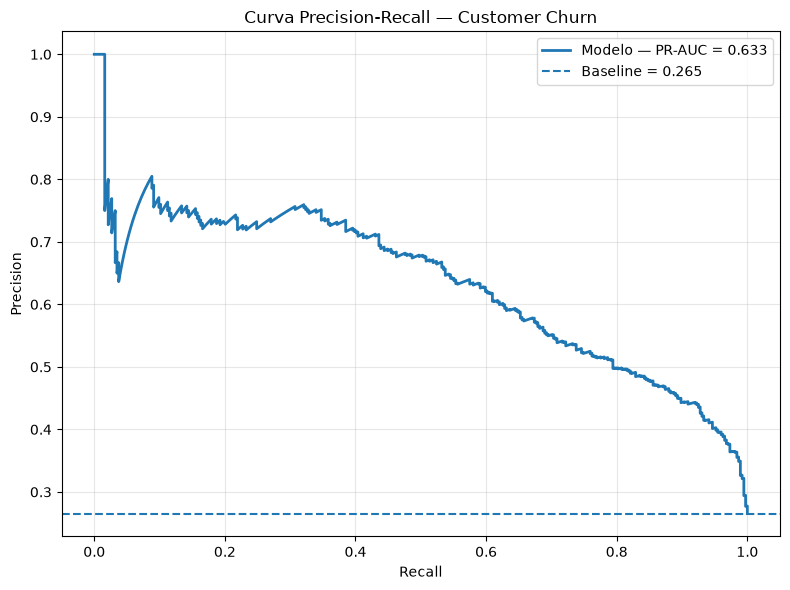

In [497]:
# ============================================
# CURVAS ROC E PRECISION-RECALL
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# Probabilidades previstas pelo modelo final
y_test_proba = model_final.predict_proba(X_test)[:, 1]

# --------------------------------------------
# ROC
# --------------------------------------------

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Modelo — AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (Recall)")
plt.title("Curva ROC — Customer Churn")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# --------------------------------------------
# PRECISION-RECALL
# --------------------------------------------

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

baseline = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Modelo — PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Customer Churn")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

===== MATRIZ DE CONFUSÃO — THRESHOLD 0.38 =====
[[835 200]
 [117 257]]


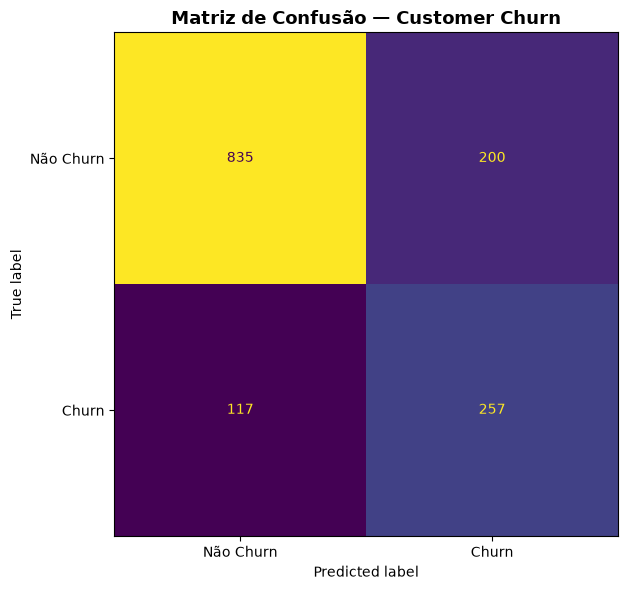

In [499]:
# ============================================
# MATRIZ DE CONFUSÃO — THRESHOLD 0.38
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Probabilidades de churn
y_test_proba = model_final.predict_proba(X_test)[:, 1]

# Aplicar threshold final
threshold = 0.38
y_test_pred = (y_test_proba >= threshold).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_test_pred)

print("===== MATRIZ DE CONFUSÃO — THRESHOLD 0.38 =====")
print(cm)

# Criar gráfico
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Não Churn", "Churn"]
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Matriz de Confusão — Customer Churn",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

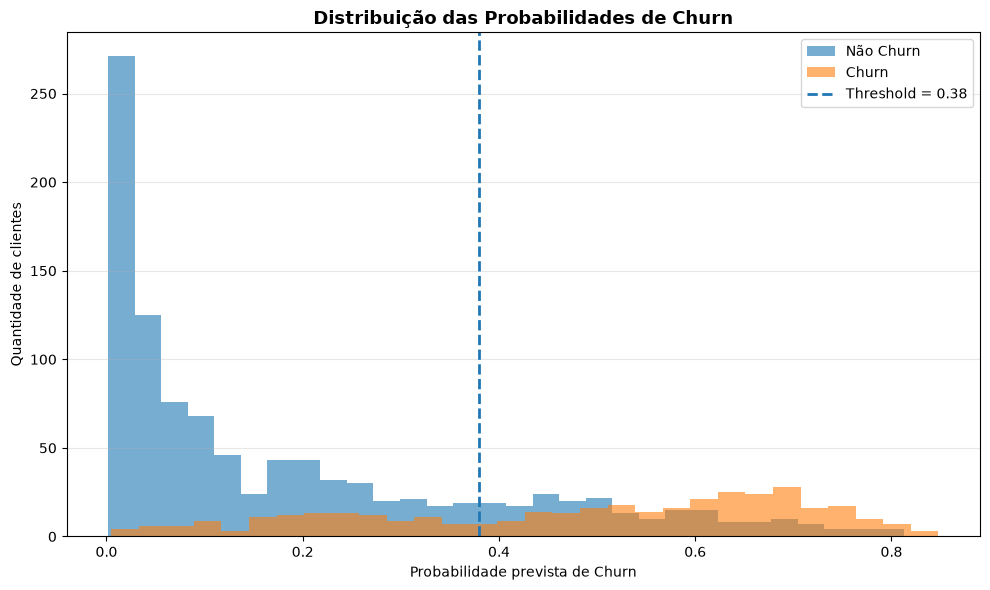

In [500]:
# ============================================
# DISTRIBUIÇÃO DAS PROBABILIDADES DE CHURN
# ============================================

import matplotlib.pyplot as plt

# Probabilidades previstas
y_test_proba = model_final.predict_proba(X_test)[:, 1]

# Separar pelas classes reais
proba_no_churn = y_test_proba[y_test == 0]
proba_churn = y_test_proba[y_test == 1]

threshold = 0.38

# Criar gráfico
plt.figure(figsize=(10, 6))

plt.hist(
    proba_no_churn,
    bins=30,
    alpha=0.6,
    label="Não Churn"
)

plt.hist(
    proba_churn,
    bins=30,
    alpha=0.6,
    label="Churn"
)

# Threshold escolhido na validação
plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {threshold}"
)

plt.xlabel("Probabilidade prevista de Churn")
plt.ylabel("Quantidade de clientes")

plt.title(
    "Distribuição das Probabilidades de Churn",
    fontsize=13,
    fontweight="bold"
)

plt.legend()
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

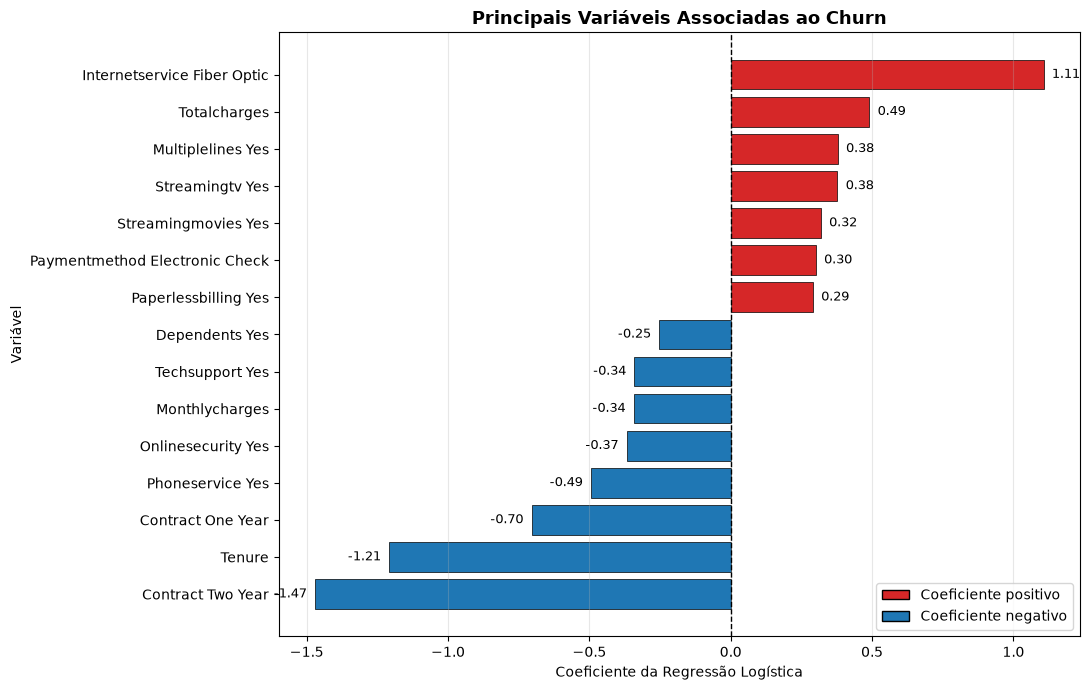

In [501]:
# ============================================
# PRINCIPAIS COEFICIENTES — MODELO FINAL
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Recuperar coeficientes do modelo final
classifier = model_final.named_steps["model"]
preprocessor_final = model_final.named_steps["preprocessor"]

# Nomes das features após preprocessing
feature_names = preprocessor_final.get_feature_names_out()

# Coeficientes
coefficients = classifier.coef_[0]

# Criar dataframe
feature_importance_final = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Selecionar os 15 maiores em magnitude
top_features = (
    feature_importance_final
    .assign(
        AbsCoefficient=lambda x: x["Coefficient"].abs()
    )
    .sort_values(
        "AbsCoefficient",
        ascending=False
    )
    .head(15)
    .sort_values("Coefficient")
    .reset_index(drop=True)
)

# Nomes mais legíveis
top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

# Cores
colors = top_features["Coefficient"].apply(
    lambda x: "#d62728" if x > 0 else "#1f77b4"
)

# Criar gráfico
fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top_features["Feature"],
    top_features["Coefficient"],
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

# Linha zero
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

# Valores dos coeficientes
max_coef = top_features["Coefficient"].abs().max()
offset = max_coef * 0.02

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + offset if width > 0 else width - offset,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        ha="left" if width > 0 else "right",
        fontsize=9
    )

# Legenda
legend_elements = [
    Patch(
        facecolor="#d62728",
        edgecolor="black",
        label="Coeficiente positivo"
    ),
    Patch(
        facecolor="#1f77b4",
        edgecolor="black",
        label="Coeficiente negativo"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower right"
)

# Formatação
ax.set_xlabel(
    "Coeficiente da Regressão Logística"
)

ax.set_ylabel(
    "Variável"
)

ax.set_title(
    "Principais Variáveis Associadas ao Churn",
    fontsize=13,
    fontweight="bold"
)

ax.grid(
    True,
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [503]:
# Verificar as etapas do Pipeline
print("===== ETAPAS DO MODEL_FINAL =====")

for nome, etapa in model_final.named_steps.items():
    print(f"{nome}: {type(etapa).__name__}")

===== ETAPAS DO MODEL_FINAL =====
preprocessor: ColumnTransformer
model: LogisticRegression


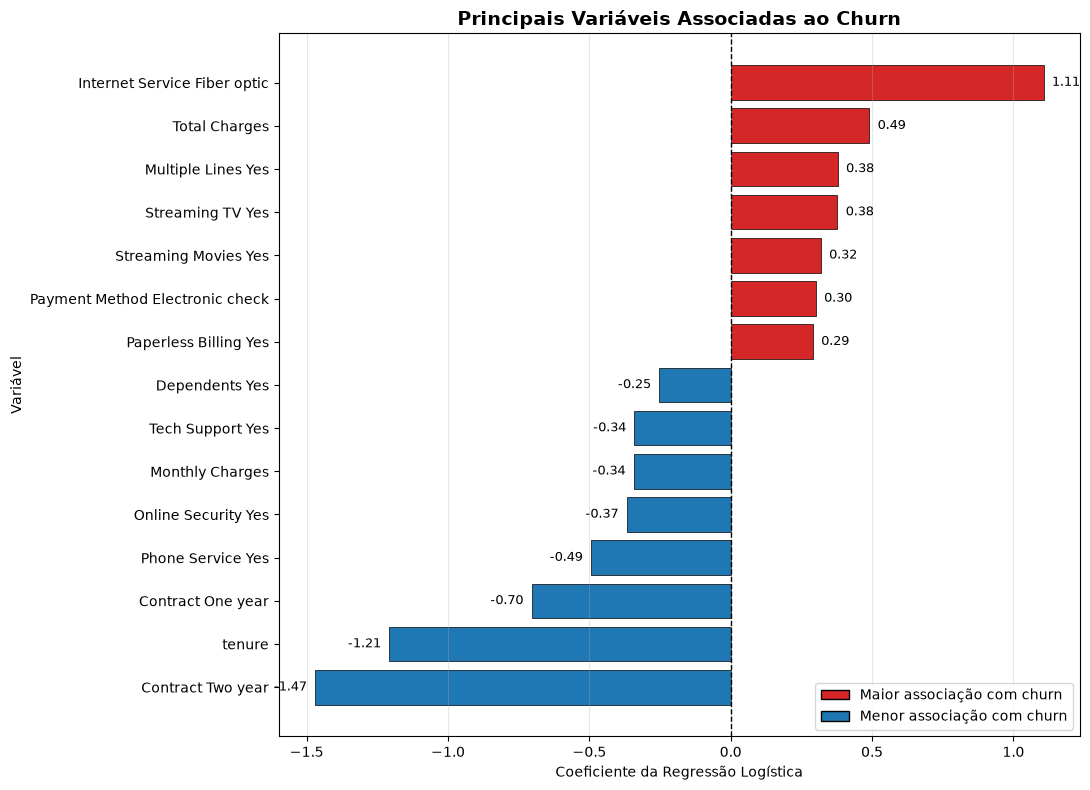

In [505]:
# ============================================
# PRINCIPAIS VARIÁVEIS ASSOCIADAS AO CHURN
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Recuperar o preprocessador e o modelo do Pipeline
preprocessor_final = model_final.named_steps["preprocessor"]
classifier_final = model_final.named_steps["model"]

# Recuperar os nomes das features após o One-Hot Encoding
feature_names = preprocessor_final.get_feature_names_out()

# Recuperar os coeficientes da Regressão Logística
coefficients = classifier_final.coef_[0]

# Criar tabela de importância
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Selecionar as 15 variáveis com maior magnitude
top_features = (
    feature_importance
    .assign(AbsCoefficient=lambda x: x["Coefficient"].abs())
    .sort_values("AbsCoefficient", ascending=False)
    .head(15)
    .sort_values("Coefficient")
    .reset_index(drop=True)
)

# Tornar os nomes mais legíveis
top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.replace("InternetService", "Internet Service", regex=False)
    .str.replace("PaymentMethod", "Payment Method", regex=False)
    .str.replace("PaperlessBilling", "Paperless Billing", regex=False)
    .str.replace("MonthlyCharges", "Monthly Charges", regex=False)
    .str.replace("TotalCharges", "Total Charges", regex=False)
    .str.replace("SeniorCitizen", "Senior Citizen", regex=False)
    .str.replace("OnlineSecurity", "Online Security", regex=False)
    .str.replace("OnlineBackup", "Online Backup", regex=False)
    .str.replace("DeviceProtection", "Device Protection", regex=False)
    .str.replace("TechSupport", "Tech Support", regex=False)
    .str.replace("StreamingTV", "Streaming TV", regex=False)
    .str.replace("StreamingMovies", "Streaming Movies", regex=False)
    .str.replace("MultipleLines", "Multiple Lines", regex=False)
    .str.replace("PhoneService", "Phone Service", regex=False)
    .str.replace("Contract", "Contract", regex=False)
)

# Definir cores de acordo com a direção do coeficiente
colors = [
    "#d62728" if coefficient > 0 else "#1f77b4"
    for coefficient in top_features["Coefficient"]
]

# Criar gráfico
fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    top_features["Feature"],
    top_features["Coefficient"],
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

# Linha de referência em zero
ax.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1
)

# Adicionar valores dos coeficientes
offset = top_features["Coefficient"].abs().max() * 0.02

for bar, coefficient in zip(bars, top_features["Coefficient"]):
    if coefficient >= 0:
        ax.text(
            coefficient + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{coefficient:.2f}",
            va="center",
            ha="left",
            fontsize=9
        )
    else:
        ax.text(
            coefficient - offset,
            bar.get_y() + bar.get_height() / 2,
            f"{coefficient:.2f}",
            va="center",
            ha="right",
            fontsize=9
        )

# Legenda
legend_elements = [
    Patch(
        facecolor="#d62728",
        edgecolor="black",
        label="Maior associação com churn"
    ),
    Patch(
        facecolor="#1f77b4",
        edgecolor="black",
        label="Menor associação com churn"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower right"
)

# Formatação
ax.set_xlabel("Coeficiente da Regressão Logística")
ax.set_ylabel("Variável")
ax.set_title(
    "Principais Variáveis Associadas ao Churn",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    True,
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

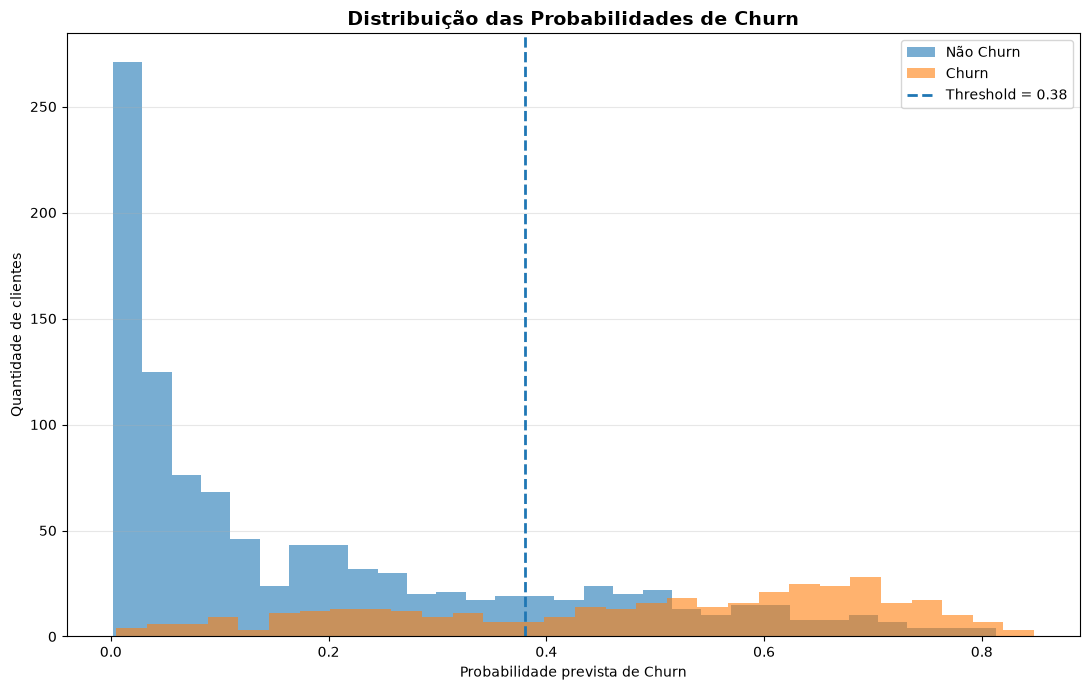

In [506]:
# ============================================
# DISTRIBUIÇÃO DAS PROBABILIDADES DE CHURN
# ============================================

import matplotlib.pyplot as plt

# Probabilidades previstas pelo modelo
y_test_proba = model_final.predict_proba(X_test)[:, 1]

# Separar probabilidades por classe real
proba_no_churn = y_test_proba[y_test == 0]
proba_churn = y_test_proba[y_test == 1]

# Threshold definido na validação
threshold_final = 0.38

# Criar gráfico
plt.figure(figsize=(11, 7))

plt.hist(
    proba_no_churn,
    bins=30,
    alpha=0.6,
    label="Não Churn"
)

plt.hist(
    proba_churn,
    bins=30,
    alpha=0.6,
    label="Churn"
)

# Threshold
plt.axvline(
    threshold_final,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {threshold_final:.2f}"
)

plt.xlabel("Probabilidade prevista de Churn")
plt.ylabel("Quantidade de clientes")
plt.title(
    "Distribuição das Probabilidades de Churn",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [507]:
# TABELA FINAL — RESULTADOS DO MODELO

import pandas as pd

metrics_final = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Threshold"
    ],
    "Resultado": [
        accuracy_final,
        precision_final,
        recall_final,
        f1_final,
        roc_auc_final,
        pr_auc_final,
        threshold_final
    ]
})

metrics_final["Resultado"] = metrics_final["Resultado"].apply(
    lambda x: f"{x:.2%}" if x <= 1 else f"{x:.2f}"
)

print("===== RESULTADOS FINAIS — MODELO DE CUSTOMER CHURN =====")
display(metrics_final)

===== RESULTADOS FINAIS — MODELO DE CUSTOMER CHURN =====


,Métrica,Resultado
0,Accuracy,77.50%
1,Precision,56.24%
2,Recall,68.72%
3,F1-score,61.85%
4,ROC-AUC,84.25%
5,PR-AUC,63.30%
6,Threshold,38.00%


In [508]:
# ============================================
# RESULTADOS FINAIS — MODELO DE CUSTOMER CHURN
# ============================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Probabilidades previstas no conjunto de teste
y_test_proba = model_final.predict_proba(X_test)[:, 1]

# Threshold definido na validação
threshold_final = 0.38

# Classificação usando o threshold final
y_test_pred = (y_test_proba >= threshold_final).astype(int)

# Métricas
metrics_final = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Threshold"
    ],
    "Resultado": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba),
        average_precision_score(y_test, y_test_proba),
        threshold_final
    ]
})

# Formatação
metrics_final["Resultado"] = metrics_final["Resultado"].apply(
    lambda x: f"{x:.2%}"
)

print("===== RESULTADOS FINAIS — MODELO DE CUSTOMER CHURN =====")

display(metrics_final)

===== RESULTADOS FINAIS — MODELO DE CUSTOMER CHURN =====


,Métrica,Resultado
0,Accuracy,77.50%
1,Precision,56.24%
2,Recall,68.72%
3,F1-score,61.85%
4,ROC-AUC,84.25%
5,PR-AUC,63.30%
6,Threshold,38.00%
